In [1]:
import matplotlib.pyplot as plt
import pandas as pd

base_abc = pd.read_csv("Base_ABC_Flor-Colheita.csv")
base_abc.head()

,uuid_sub_talhao,uuid_talhao_safra,uuid_fazenda,Cooperativa,Safra,Altitude Mínima [m],Altitude Média [m],Altitude Máxima [m],Altitude Média [classe],Solo Grupo,...,ND.TMOL > 20 [sum],ND.TMOL > 22 [sum],ND.TMOL > 24 [sum],ND.TMOL > 26 [sum],ND.TMOL > 28 [sum],Amplitude Térmica [soma],ND.AMPLIT > 12 [sum],ND.AMPLIT > 16 [sum],ND.AMPLIT > 20 [sum],ND.AMPLIT > 24 [sum]
0,0017d88e-26bf-42d2-9f4c-7eb438fff2ed,0e113ef0-a96d-4380-a52c-b002144cc153,8daefa63-3408-4e07-98fb-edacea36073f,Castrolanda,2023/2024,778.0,815.0,846.0,801 a 900,Neossolos Litólicos Distróficos,...,"38,0","12,0","2,0","0,0","0,0","830,5","33,0","2,0","0,0","0,0"
1,0044b084-9661-4b71-8ef0-12190a6d2cc0,7106f884-5f42-4554-8404-8b3d38231a11,2a4d28e8-0574-4796-9d93-eea9200b7287,Castrolanda,2023/2024,971.0,989.0,1021.0,901 a 1000,Latossolos Vermelhos Distróficos,...,"24,0","0,0","0,0","0,0","0,0","909,0","27,0","5,0","0,0","0,0"
2,0047f2ed-6583-4163-93db-6f91e515f6a2,7dcfef66-0d93-4460-9cf3-f25fe26e7929,06a1c642-9a3a-42ea-ae98-a6670106741e,Castrolanda,2023/2024,983.0,998.0,1017.0,901 a 1000,Organossolos Mésicos,...,"13,0","0,0","0,0","0,0","0,0","821,0","41,0","8,0","0,0","0,0"
3,0058f085-a0ae-46cd-bdbf-821788eba645,09c5cc37-4160-4b3b-9b7a-4ecb0857288e,b2c741d1-e357-428f-8bbf-1ecba2b032c4,Castrolanda,2023/2024,984.0,1000.0,1017.0,901 a 1000,Latossolos Brunos Ácricos,...,"24,0","0,0","0,0","0,0","0,0","934,4","29,0","6,0","0,0","0,0"
4,005d144c-42b7-41cf-a042-8284f54dfe8e,fdb3a21a-0b0c-485d-8cbd-ddd80e4ea7f0,df74756c-5ff2-46b4-b307-d35e1c5c30d7,Castrolanda,2023/2024,961.0,1038.0,1078.0,1001 a 1100,Latossolos Vermelhos Distróficos,...,"13,0","3,0","0,0","0,0","0,0","402,9","15,0","5,0","0,0","0,0"


In [2]:
variaveis = [ 
    "UF",
    "NH.TMED < 10 [sum]",
    "ND.TMIN < 10 [sum]",
    "Altitude Média [classe]",
    "Semeadura [data]",
    "Colheita [data]",
    "Genótipos Propósito",
    "Tipo Safra",
    "Solo Textura",
    "Talhão",
    "Solo Grupo",
    "Amplitude Térmica [soma]",
    "Temperatura Ar Mínima [soma]",
    "Temperatura Ar Máxima [soma]",
    "Fotoperiodo [soma]",
    "Genótipos",
    "Precipitação [soma]",
    "Graus Dias [soma]",
    "Temperatura Ar [soma]",
    "Umidade Relativa Máxima [soma]",
    "Umidade Relativa Mínima [soma]",
    "Umidade Relativa [soma]",
    "Radiação Solar [soma]",
    "Evapotranspiração Potencial PM [soma]",
    "Evapotranspiração Potencial PM2 [soma]",
    "Temperatura Orvalho [soma]",
    "Temperatura Ar Noturna [ºC]",
    "Temperatura Molhamento Foliar [soma]",
    "Altitude Máxima [m]",
    "Altitude Média [m]",
    "Altitude Mínima [m]",
    "NH.UR > 90 [sum]",
    "Ciclo Semeadura-Colheita [dias]",
    "Fungicida Planejado [aplicações]",
    "Herbicida Planejado [aplicações]",
    "Inseticida Planejado [aplicações]",
    "ND.UR < 60 [sum]",
    "ND.UR > 80 [sum]",
    "ND.UR > 90 [sum]",
    "NH.UR < 60 [sum]",
    "Talhão Latitude [grau decimal]",
    "Talhão Longitude [grau decimal]",
    "Colheita [decendio]",
    "ND.RAD < 10 [sum]",
    "ND.PREC > 5 [sum]",
    "NH.RAD > 800 [sum]",
    "Semeadura [decendio]",
    "ND.PREC = 0.0 [sum]",
    "ND.TMAX > 30 [sum]",
    "ND.PREC > 0.2 [sum]",
    "ND.RAD > 20 [sum]",
    "NH.RAD > 1000 [sum]",
    "NH.RAD > 600 [sum]",
]

base_abc_X  = base_abc[variaveis].copy()
base_abc_Y = base_abc["Produtividade Realizada [kg/ha]"]

base_abc_X["Semeadura [data]"] = pd.to_datetime(base_abc_X["Semeadura [data]"], errors='coerce')
base_abc_X["Colheita [data]"] = pd.to_datetime(base_abc_X["Colheita [data]"], errors='coerce')

for col in ["Semeadura [data]", "Colheita [data]"]:
    base_abc_X[f"{col}_ano"] = base_abc_X[col].dt.year
    base_abc_X[f"{col}_mes"] = base_abc_X[col].dt.month
    base_abc_X[f"{col}_dia"] = base_abc_X[col].dt.day

In [3]:
variaveis_categoricas = [
    "UF",
    "Altitude Média [classe]",
    "Genótipos Propósito",
    "Tipo Safra",
    "Solo Textura",
    "Talhão",
    "Solo Grupo",
    "Genótipos"
]

variaveis_numericas = [
    "NH.TMED < 10 [sum]",
    "ND.TMIN < 10 [sum]",
    "Amplitude Térmica [soma]",
    "Temperatura Ar Mínima [soma]",
    "Temperatura Ar Máxima [soma]",
    "Fotoperiodo [soma]",
    "Precipitação [soma]",
    "Graus Dias [soma]",
    "Temperatura Ar [soma]",
    "Umidade Relativa Máxima [soma]",
    "Umidade Relativa Mínima [soma]",
    "Umidade Relativa [soma]",
    "Radiação Solar [soma]",
    "Evapotranspiração Potencial PM [soma]",
    "Evapotranspiração Potencial PM2 [soma]",
    "Temperatura Orvalho [soma]",
    "Temperatura Ar Noturna [ºC]",
    "Temperatura Molhamento Foliar [soma]",
    "NH.UR > 90 [sum]",
    "ND.UR < 60 [sum]",
    "ND.UR > 80 [sum]",
    "ND.UR > 90 [sum]",
    "NH.UR < 60 [sum]",
    "Talhão Latitude [grau decimal]",
    "Talhão Longitude [grau decimal]",
    "ND.RAD < 10 [sum]",
    "ND.PREC > 5 [sum]",
    "NH.RAD > 800 [sum]",
    "ND.PREC = 0.0 [sum]",
    "ND.TMAX > 30 [sum]",
    "ND.PREC > 0.2 [sum]",
    "ND.RAD > 20 [sum]",
    "NH.RAD > 1000 [sum]",
    "NH.RAD > 600 [sum]",
    "Semeadura [data]_ano",
    "Semeadura [data]_mes",
    "Semeadura [data]_dia",
    "Colheita [data]_ano",
    "Colheita [data]_mes",
    "Colheita [data]_dia",
    "Colheita [decendio]",
    "Semeadura [decendio]",
    "Inseticida Planejado [aplicações]",
    "Fungicida Planejado [aplicações]",
    "Herbicida Planejado [aplicações]",
    "Altitude Máxima [m]",
    "Altitude Média [m]",
    "Altitude Mínima [m]",
    "Ciclo Semeadura-Colheita [dias]",
]

#transforma valores que estavam sendo interpretados como str em valores numericos
for col in variaveis_numericas:
    if base_abc_X[col].dtype == "object":
        base_abc_X[col] = (
            base_abc_X[col].str.replace(".", "", regex=False)
            .str.replace(",", ".", regex=False)
            .astype(float)
        )

In [4]:
mlp_variaveis = [
    "UF",
    "ND.TMIN < 10 [sum]",
    "Altitude Média [classe]",
    "Genótipos Propósito",
    "Solo Textura",
    "Solo Grupo",
    "Genótipos",
    "Umidade Relativa Mínima [soma]",
    "Umidade Relativa [soma]",
    "Inseticida Planejado [aplicações]",
    "Talhão Latitude [grau decimal]",
    "Colheita [data]_mes",
    "Colheita [data]_dia",
]

knn_variaveis = [
    "Genótipos Propósito",
    "Tipo Safra",
    "Altitude Máxima [m]",
    "NH.UR > 90 [sum]",
    "Fungicida Planejado [aplicações]",
    "Herbicida Planejado [aplicações]",
    "Inseticida Planejado [aplicações]",
    "ND.UR > 80 [sum]",
    "ND.UR > 90 [sum]",
    "Talhão Latitude [grau decimal]",
    "Talhão Longitude [grau decimal]",
    "Semeadura [decendio]",
    "ND.TMAX > 30 [sum]",
    "NH.RAD > 1000 [sum]",
    "Colheita [data]_mes",
]

rf_variaveis = [
    "Genótipos Propósito",
    "Solo Textura",
    "Genótipos",
    "Fungicida Planejado [aplicações]",
    "Herbicida Planejado [aplicações]",
    "Inseticida Planejado [aplicações]",
    "Talhão Latitude [grau decimal]",
    "Talhão Longitude [grau decimal]",
    "Colheita [decendio]",
    "ND.RAD < 10 [sum]",
    "Semeadura [decendio]",
    "ND.TMAX > 30 [sum]",
]

dt_variaveis = [
    "ND.TMIN < 10 [sum]",
    "Colheita [data]",
    "Genótipos Propósito",
    "Talhão",
    "Genótipos",
    "Evapotranspiração Potencial PM [soma]",
    "Herbicida Planejado [aplicações]",
    "ND.UR < 60 [sum]",
    "Talhão Latitude [grau decimal]",
    "Talhão Longitude [grau decimal]",
    "Colheita [decendio]",
    "Semeadura [decendio]",
    "ND.PREC = 0.0 [sum]",
    "Colheita [data]_mes",
]

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.base import BaseEstimator, TransformerMixin

class FeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(self, selected_columns):
        self.selected_columns = selected_columns

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X[self.selected_columns]

def build_preprocessor_from_vars(selected_vars):
    num_cols = [c for c in variaveis_numericas if c in selected_vars]
    cat_cols = [c for c in variaveis_categoricas if c in selected_vars]

    transformers = []

    if num_cols:
        transformers.append((
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="mean")),
                ("scaler", StandardScaler())
            ]),
            num_cols
        ))

    if cat_cols:
        transformers.append((
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            cat_cols
        ))

    return ColumnTransformer(transformers)

In [11]:
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

mlp_pipeline = Pipeline(steps=[
    ("selector", FeatureSelector(mlp_variaveis)),
    ("preprocess", build_preprocessor_from_vars(mlp_variaveis)),
    ("regressor", MLPRegressor())
])

knn_pipeline = Pipeline(steps=[
    ("selector", FeatureSelector(knn_variaveis)),
    ("preprocess", build_preprocessor_from_vars(knn_variaveis)),
    ("regressor", KNeighborsRegressor())
])

dt_pipeline = Pipeline(steps=[
    ("selector", FeatureSelector(dt_variaveis)),
    ("preprocess", build_preprocessor_from_vars(dt_variaveis)),
    ("regressor", DecisionTreeRegressor())
])

rf_pipeline = Pipeline(steps=[
    ("selector", FeatureSelector(rf_variaveis)),
    ("preprocess", build_preprocessor_from_vars(rf_variaveis)),
    ("regressor", RandomForestRegressor())
])

In [12]:
#MLP
mlp_score = cross_val_score(mlp_pipeline, base_abc_X, base_abc_Y, cv = 5, scoring='r2')
print(mlp_score)

c:\Users\danie\dev\ic\env\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\danie\dev\ic\env\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\danie\dev\ic\env\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\danie\dev\ic\env\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


[0.39031101 0.42148971 0.40858364 0.42507393 0.38665658]


c:\Users\danie\dev\ic\env\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [14]:
#KNN
knn_score = cross_val_score(knn_pipeline, base_abc_X , base_abc_Y, cv = 5, scoring='r2')
print(knn_score)

[0.49953355 0.47593996 0.53017085 0.47750231 0.48998029]


In [15]:
#Decision Tree
dt_score = cross_val_score(dt_pipeline, base_abc_X , base_abc_Y, cv = 5, scoring='r2')
print(dt_score)

[0.28533913 0.27949822 0.36864084 0.22705205 0.22397548]


In [16]:
#Random Forest
rf_score = cross_val_score(rf_pipeline, base_abc_X , base_abc_Y, cv = 5, scoring = 'r2')
print(rf_score)

[0.60238698 0.61617825 0.64322271 0.61835187 0.60665667]


In [17]:
import numpy as np

models = ['Random Forest', 'KNeighboors', 'Decision Tree', 'MLP']

#Calculando a média dos resultados de cada modelo
scores = [
    np.mean(rf_score),
    np.mean(knn_score),
    np.mean(dt_score),
    np.mean(mlp_score)
]

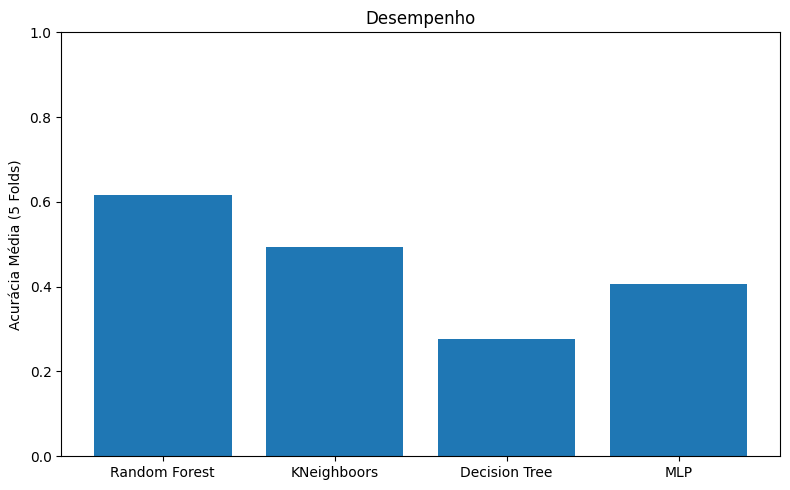

In [18]:
plt.figure(figsize=(8, 5))
plt.bar(models, scores)

plt.ylabel('Acurácia Média (5 Folds)')
plt.title('Desempenho')
plt.ylim(0.0, 1) #Mostra de 0 até 1

plt.tight_layout()
plt.show()